# Segmentation de la clientèle Mobile Money — Guinée

**Objectif** : construire une segmentation actionnable de la clientèle à partir de l'historique de transactions (6 mois, ~50 000 transactions, 5 000 clients), afin de personnaliser les offres marketing.

**Plan**
1. Chargement et qualité des données
2. Feature engineering client (RFM + indicateurs avancés)
3. Traitement des valeurs aberrantes
4. Normalisation et ACP
5. Clustering K-means (choix de K, stabilité)
6. Classification Hiérarchique Ascendante (CHA) et comparaison
7. Caractérisation et nommage des segments
8. Recommandations marketing


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.manifold import TSNE

RANDOM_SEED = 42
sns.set_theme(style="whitegrid", palette="Set2")
%matplotlib inline
pd.set_option("display.max_columns", 50)


## 1. Chargement et qualité des données

Les données brutes contiennent une ligne par transaction : `client_id`, `type_transaction`, `montant`, `date_transaction`, `heure_transaction`.
On vérifie doublons, valeurs manquantes et montants invalides (≤ 0) avant toute agrégation — une erreur de qualité en amont se propage dans toutes les features clients.

In [2]:
df = pd.read_csv("../data/transactions_mobile_money.csv", parse_dates=["date_transaction"])
print(f"Lignes brutes : {len(df)}")
df.head()


Lignes brutes : 50000


,client_id,type_transaction,montant,date_transaction,heure_transaction
0,CLI00001,transfert,155000.0,2026-02-17,14:03:21
1,CLI00001,depot,154500.0,2026-04-13,19:35:51
2,CLI00001,retrait,199000.0,2026-07-21,10:06:44
3,CLI00002,retrait,8000.0,2026-02-21,11:51:16
4,CLI00002,achat_credit,12500.0,2026-03-06,08:27:32


In [3]:
n_dup = df.duplicated().sum()
df = df.drop_duplicates()
n_missing = df.isna().sum().sum()
df = df.dropna(subset=["client_id", "type_transaction", "montant", "date_transaction"])
df = df[df["montant"] > 0]

print(f"Doublons supprimés : {n_dup}")
print(f"Valeurs manquantes supprimées : {n_missing}")
print(f"Transactions valides : {len(df)} | Clients uniques : {df['client_id'].nunique()}")


Doublons supprimés : 0
Valeurs manquantes supprimées : 0
Transactions valides : 50000 | Clients uniques : 5000


Période couverte : 183 jours, date de référence (pour la récence) : 2026-07-28


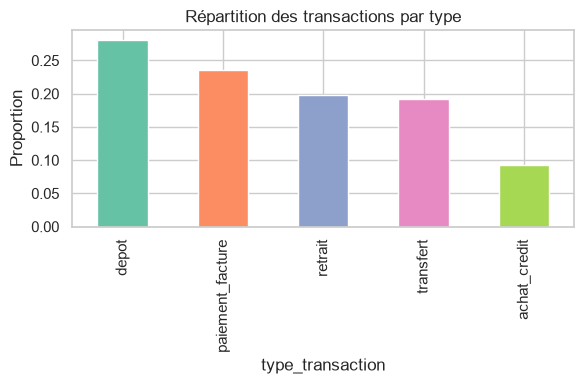

In [4]:
REF_DATE = df["date_transaction"].max() + pd.Timedelta(days=1)
PERIOD_DAYS = (df["date_transaction"].max() - df["date_transaction"].min()).days + 1
print(f"Période couverte : {PERIOD_DAYS} jours, date de référence (pour la récence) : {REF_DATE.date()}")

df["type_transaction"].value_counts(normalize=True).plot.bar(figsize=(6,4), color=sns.color_palette("Set2"))
plt.ylabel("Proportion")
plt.title("Répartition des transactions par type")
plt.tight_layout()
plt.show()


## 2. Feature engineering client

On transforme le journal de transactions en **un vecteur de features par client**. Chaque variable est choisie pour son apport métier direct :

| Variable | Apport métier |
|---|---|
| `recence` | Jours depuis dernière transaction → détecte le désengagement / churn |
| `frequence` | Nombre total de transactions → intensité d'usage du service |
| `montant_total` | Volume total généré → valeur économique du client |
| `montant_moyen` | Ticket moyen → positionnement (petit porteur vs gros utilisateur) |
| `montant_std`, `cv_montant` | Volatilité des montants → régularité vs usage occasionnel de gros montants |
| `freq_hebdo_moyenne` | Fréquence normalisée par ancienneté → comparable entre anciens et nouveaux clients |
| `pct_<type>` | Répartition par type de transaction → intention d'usage (épargne, paiement de factures, transfert social, crédit tel.) |

Le RFM classique (Récence, Fréquence, Montant) est ainsi enrichi d'indicateurs comportementaux nécessaires pour distinguer, par exemple, un gros épargnant occasionnel d'un client actif à petits montants quotidiens — deux profils que le RFM seul confondrait.

In [5]:
agg = df.groupby("client_id").agg(
    recence=("date_transaction", lambda x: (REF_DATE - x.max()).days),
    premiere_transaction=("date_transaction", "min"),
    frequence=("montant", "count"),
    montant_total=("montant", "sum"),
    montant_moyen=("montant", "mean"),
    montant_std=("montant", "std"),
)
agg["montant_std"] = agg["montant_std"].fillna(0.0)
agg["anciennete_jours"] = (REF_DATE - agg["premiere_transaction"]).dt.days.clip(lower=1)
agg["freq_hebdo_moyenne"] = agg["frequence"] / (agg["anciennete_jours"] / 7)

type_counts = df.pivot_table(index="client_id", columns="type_transaction",
                              values="montant", aggfunc="count", fill_value=0)
type_props = type_counts.div(type_counts.sum(axis=1), axis=0)
type_props.columns = [f"pct_{c}" for c in type_props.columns]

client_df = agg.join(type_props).drop(columns=["premiere_transaction"])
client_df["cv_montant"] = (client_df["montant_std"] / client_df["montant_moyen"]).replace(
    [np.inf, -np.inf], 0).fillna(0)

print(f"Dataset client : {client_df.shape[0]} clients x {client_df.shape[1]} variables")
client_df.describe().T.round(2)


Dataset client : 5000 clients x 13 variables


,count,mean,std,min,25%,50%,75%,max
recence,5000.0,36.45,42.82,1.00,6.00,17.00,53.00,183.00
frequence,5000.0,10.00,8.22,1.00,2.00,7.00,17.00,33.00
montant_total,5000.0,2658267.42,5216926.19,3500.00,47500.00,536500.00,1673625.00,42820508.70
montant_moyen,5000.0,179342.61,283943.21,3500.00,18833.33,47879.81,132000.00,2489418.92
montant_std,5000.0,125883.97,319623.91,0.00,3697.40,23221.19,54500.98,6593608.35
anciennete_jours,5000.0,147.31,42.81,1.00,132.00,167.00,178.00,183.00
freq_hebdo_moyenne,5000.0,0.46,0.43,0.04,0.13,0.44,0.71,7.00
pct_achat_credit,5000.0,0.15,0.26,0.00,0.00,0.05,0.15,1.00
pct_depot,5000.0,0.21,0.25,0.00,0.00,0.12,0.35,1.00
pct_paiement_facture,5000.0,0.18,0.26,0.00,0.00,0.05,0.23,1.00


## 3. Traitement des valeurs aberrantes

Les montants et fréquences suivent des distributions à queue lourde (quelques clients très gros porteurs). On applique une **winsorisation aux 1er/99e percentiles** plutôt qu'une suppression : elle réduit l'influence des extrêmes sur K-means (sensible à la distance euclidienne) sans perdre de clients ni fausser les tailles de segments. Documenté ci-dessous pour traçabilité.

In [6]:
FEATURES = [
    "recence", "frequence", "montant_total", "montant_moyen", "montant_std",
    "freq_hebdo_moyenne", "cv_montant",
    "pct_depot", "pct_retrait", "pct_transfert", "pct_paiement_facture", "pct_achat_credit",
]
for c in ["pct_depot", "pct_retrait", "pct_transfert", "pct_paiement_facture", "pct_achat_credit"]:
    if c not in client_df.columns:
        client_df[c] = 0.0

X_raw = client_df[FEATURES].copy()

capped_cols = ["montant_total", "montant_moyen", "montant_std", "freq_hebdo_moyenne", "frequence"]
outlier_report = {}
for c in capped_cols:
    lo, hi = X_raw[c].quantile([0.01, 0.99])
    n_out = ((X_raw[c] < lo) | (X_raw[c] > hi)).sum()
    outlier_report[c] = {"lo": round(float(lo), 1), "hi": round(float(hi), 1), "n_capped": int(n_out)}
    X_raw[c] = X_raw[c].clip(lo, hi)

pd.DataFrame(outlier_report).T


,lo,hi,n_capped
montant_total,7000.0,20804580.0,94.0
montant_moyen,5500.0,1093412.8,94.0
montant_std,0.0,1164007.2,50.0
freq_hebdo_moyenne,0.0,1.2,99.0
frequence,1.0,27.0,38.0


**Transformation log1p** : les variables monétaires et de comptage restent fortement asymétriques même après écrêtage. Sans transformation, K-means (distance euclidienne) sépare essentiellement selon un seul axe « gros montants vs petits montants » et masque les nuances de comportement (type de transaction, régularité) — on observe alors un K optimal dégénéré à 2 clusters. Le log1p ramène ces variables à une échelle où chaque dimension contribue équitablement à la distance, condition nécessaire pour que K-means exploite les 12 variables et pas seulement la plus dispersée.

In [7]:
LOG_COLS = ["recence", "frequence", "montant_total", "montant_moyen", "montant_std", "freq_hebdo_moyenne"]
for c in LOG_COLS:
    X_raw[c] = np.log1p(X_raw[c])


## 4. Normalisation et ACP

**Z-score (StandardScaler)** plutôt que Min-Max : après écrêtage, les variables restent approximativement continues avec des échelles très différentes (jours vs GNF vs proportions) mais pas bornées naturellement. Le Min-Max est plus sensible aux valeurs extrêmes résiduelles et écrase la variance des variables à faible étendue ; le Z-score centre-réduit chaque variable pour que K-means (basé sur la distance euclidienne) ne soit pas dominé par les variables à grande échelle (ex. `montant_total` en centaines de milliers vs `pct_depot` entre 0 et 1).

L'ACP sert ici à **visualiser** la structure (pas de réduction dure de dimension avant clustering, pour garder l'interprétabilité métier des 12 variables).

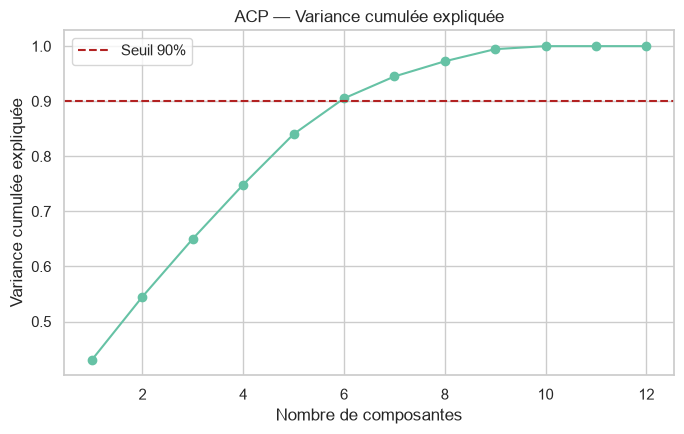

6 composantes suffisent pour expliquer >=90% de la variance.


In [8]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=FEATURES, index=X_raw.index)

pca_full = PCA(random_state=RANDOM_SEED).fit(X_scaled)
var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
n_comp_90 = int(np.argmax(cum_var >= 0.90) + 1)

plt.figure(figsize=(7,4.5))
plt.plot(range(1, len(var_ratio)+1), cum_var, marker="o")
plt.axhline(0.90, color="firebrick", linestyle="--", label="Seuil 90%")
plt.xlabel("Nombre de composantes"); plt.ylabel("Variance cumulée expliquée")
plt.title("ACP — Variance cumulée expliquée"); plt.legend(); plt.tight_layout(); plt.show()

print(f"{n_comp_90} composantes suffisent pour expliquer >=90% de la variance.")


In [9]:
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)
print(f"Variance expliquée par les 2 premières composantes : {cum_var[1]*100:.1f}%")

loadings = pd.DataFrame(pca_2d.components_.T, index=FEATURES, columns=["PC1", "PC2"])
loadings.sort_values("PC1", ascending=False)


Variance expliquée par les 2 premières composantes : 54.5%


,PC1,PC2
montant_total,0.415827,-0.024973
frequence,0.397808,0.098539
freq_hebdo_moyenne,0.374889,0.110227
montant_std,0.353939,-0.063595
montant_moyen,0.324206,-0.113522
cv_montant,0.285638,-0.186042
pct_depot,0.236959,-0.310835
pct_paiement_facture,0.125829,0.603700
pct_retrait,-0.036285,-0.281182
pct_transfert,-0.143475,-0.437992


## 5. Clustering K-means — choix de K

On teste K de 2 à 10 avec **n_init=10** (10 initialisations aléatoires par K, on garde le meilleur run) pour limiter la sensibilité à l'initialisation. Deux critères combinés :
- **Méthode du coude** : recherche du point où l'inertie intra-cluster cesse de diminuer fortement.
- **Score de silhouette** : mesure la séparation/cohésion des clusters (proche de 1 = bien séparés), plus robuste que le coude seul pour trancher.

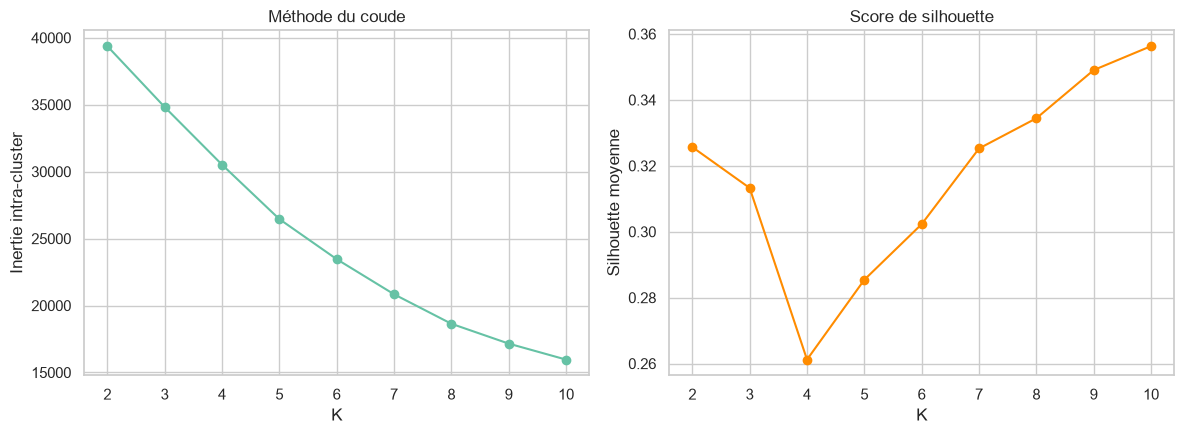

In [10]:
K_RANGE = range(2, 11)
inertias, sil_scores = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(list(K_RANGE), inertias, marker="o")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertie intra-cluster"); axes[0].set_title("Méthode du coude")
axes[1].plot(list(K_RANGE), sil_scores, marker="o", color="darkorange")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette moyenne"); axes[1].set_title("Score de silhouette")
plt.tight_layout(); plt.show()


**Choix de K** : le maximum global de silhouette pousse vers les bornes de la plage testée (k=2 : coupure grossière en 2 méga-groupes par volume ; k=10 : sur-fragmentation — des micro-clusters de quelques dizaines de clients dormants séparés par le seul type de leur unique transaction, sans valeur métier actionnable). On borne donc la sélection à une plage opérationnellement exploitable pour une stratégie marketing (3 à 7 segments), et on retient le maximum de silhouette à l'intérieur de cette plage : la silhouette reste le critère de décision, contraint par la faisabilité business.

In [11]:
BUSINESS_K_MIN, BUSINESS_K_MAX = 3, 7
k_list = list(K_RANGE)
business_mask = [(BUSINESS_K_MIN <= k <= BUSINESS_K_MAX) for k in k_list]
business_sil = [s if m else -np.inf for s, m in zip(sil_scores, business_mask)]
best_k = k_list[int(np.argmax(business_sil))]
print(f"K optimal retenu (silhouette max, plage business {BUSINESS_K_MIN}-{BUSINESS_K_MAX}) : {best_k}")


K optimal retenu (silhouette max, plage business 3-7) : 7


In [12]:
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_SEED)
km_labels = kmeans_final.fit_predict(X_scaled)
client_df["cluster_kmeans"] = km_labels

sil_avg = silhouette_score(X_scaled, km_labels)
sil_vals = silhouette_samples(X_scaled, km_labels)
sil_per_cluster = pd.Series(sil_vals, index=X_scaled.index).groupby(km_labels).mean()

print(f"Silhouette moyenne (k={best_k}) : {sil_avg:.3f}")
print("Silhouette moyenne par cluster :")
print(sil_per_cluster.round(3))


Silhouette moyenne (k=7) : 0.325
Silhouette moyenne par cluster :
0    0.374
1    0.323
2    0.054
3    0.431
4    0.184
5    0.437
6    0.327
dtype: float64


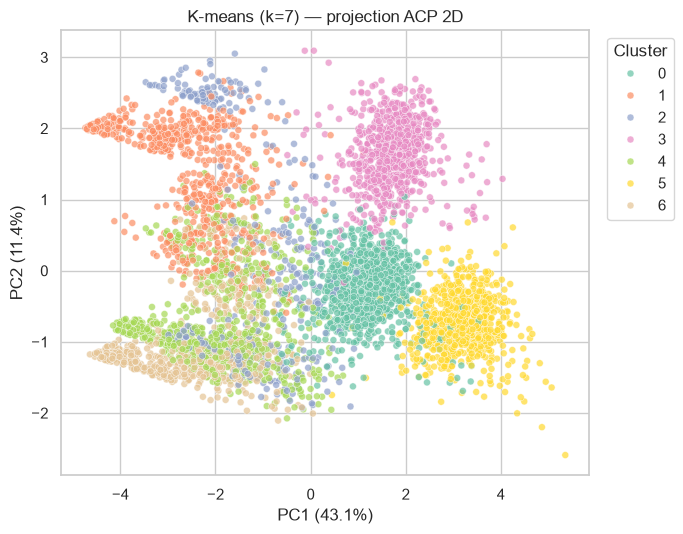

In [13]:
plt.figure(figsize=(7,5.5))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=km_labels, palette="Set2", s=25, alpha=0.7)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.title(f"K-means (k={best_k}) — projection ACP 2D")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


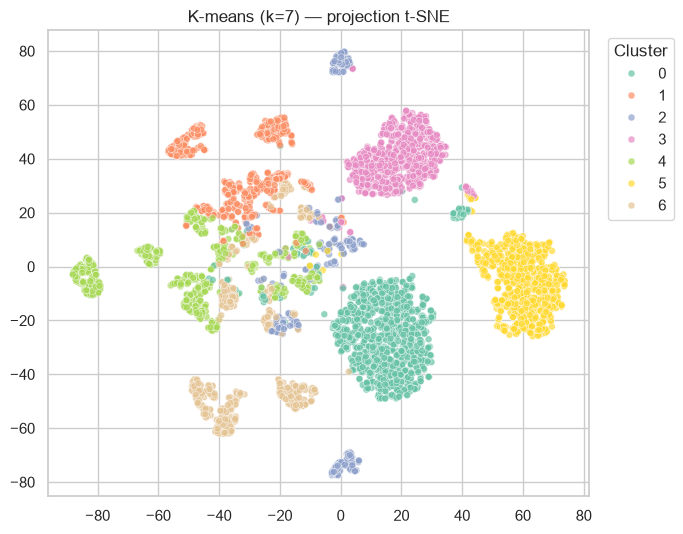

In [14]:
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize=(7,5.5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=km_labels, palette="Set2", s=25, alpha=0.7)
plt.title(f"K-means (k={best_k}) — projection t-SNE")
plt.legend(title="Cluster", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


## 6. Classification Hiérarchique Ascendante (CHA)

CHA avec **distance euclidienne** et **méthode de Ward** (minimise l'inertie intra-cluster à chaque fusion, cohérent avec le critère K-means — permet une comparaison honnête). Le dendrogramme permet de visualiser la structure hiérarchique et de valider visuellement le nombre de groupes naturels.

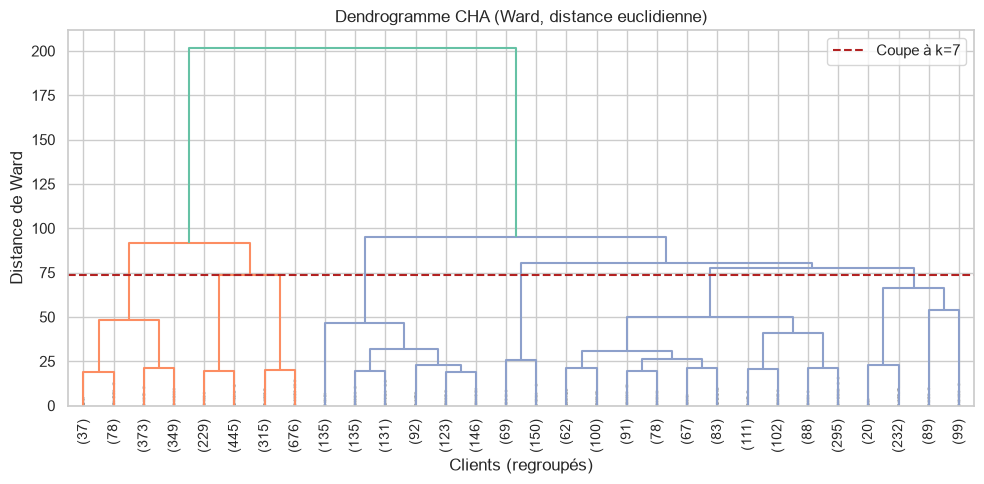

In [15]:
Z = linkage(X_scaled, method="ward", metric="euclidean")

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, show_contracted=True)
plt.axhline(y=sorted(Z[:,2])[-(best_k-1)], color="firebrick", linestyle="--", label=f"Coupe à k={best_k}")
plt.title("Dendrogramme CHA (Ward, distance euclidienne)")
plt.xlabel("Clients (regroupés)"); plt.ylabel("Distance de Ward")
plt.legend(); plt.tight_layout(); plt.show()


In [16]:
cha_labels = fcluster(Z, t=best_k, criterion="maxclust") - 1
client_df["cluster_cha"] = cha_labels

ari = adjusted_rand_score(km_labels, cha_labels)
print(f"Indice de Rand ajusté (K-means vs CHA, k={best_k}) : {ari:.3f}")
print("(1 = accord parfait, 0 = accord aléatoire — un ARI > 0.5 indique une structure de segments robuste, retrouvée par deux méthodes indépendantes)")


Indice de Rand ajusté (K-means vs CHA, k=7) : 0.672
(1 = accord parfait, 0 = accord aléatoire — un ARI > 0.5 indique une structure de segments robuste, retrouvée par deux méthodes indépendantes)


## 7. Caractérisation et nommage des segments

On calcule le profil moyen/médian/écart-type de chaque cluster K-means (solution retenue), puis on applique des règles métier pour nommer automatiquement chaque segment à partir de ses traits dominants (fréquence, montant, récence, type de transaction majoritaire).

In [17]:
profile_mean = client_df.groupby("cluster_kmeans")[FEATURES].mean()
profile_median = client_df.groupby("cluster_kmeans")[FEATURES].median()
profile_std = client_df.groupby("cluster_kmeans")[FEATURES].std()
cluster_sizes = client_df["cluster_kmeans"].value_counts().sort_index()

print("Effectifs par cluster :")
print(cluster_sizes)
profile_mean.round(2)


Effectifs par cluster :
cluster_kmeans
0    1069
1     609
2     403
3     727
4     760
5     784
6     648
Name: count, dtype: int64


,recence,frequence,montant_total,montant_moyen,montant_std,freq_hebdo_moyenne,cv_montant,pct_depot,pct_retrait,pct_transfert,pct_paiement_facture,pct_achat_credit
cluster_kmeans,,,,,,,,,,,,
0,10.99,16.92,770659.72,47554.56,33239.48,0.69,0.66,0.25,0.30,0.25,0.10,0.10
1,56.18,2.70,64923.63,35840.80,9169.99,0.21,0.29,0.04,0.04,0.12,0.04,0.76
2,77.01,1.83,235829.29,130673.05,38906.05,0.18,0.28,0.46,0.02,0.12,0.35,0.05
3,11.19,17.08,1894545.12,115163.00,58152.96,0.71,0.46,0.09,0.10,0.10,0.65,0.06
4,61.89,2.36,123569.86,59160.54,25383.86,0.16,0.35,0.06,0.64,0.18,0.05,0.08
5,10.87,17.71,13784010.30,778374.72,644329.28,0.71,0.79,0.55,0.15,0.15,0.10,0.05
6,64.15,2.20,84896.14,50088.99,9105.08,0.23,0.25,0.03,0.05,0.85,0.03,0.03


In [18]:
pct_cols = ["pct_depot", "pct_retrait", "pct_transfert", "pct_paiement_facture", "pct_achat_credit"]
overall_median = client_df[FEATURES].median()

TYPE_LABELS = {
    "pct_depot": "Épargnants / gros déposants",
    "pct_retrait": "Retraits dominants",
    "pct_transfert": "Transferts sociaux dominants",
    "pct_paiement_facture": "Payeurs de factures",
    "pct_achat_credit": "Acheteurs de crédit téléphonique",
}
DOMINANT_SHARE_THRESHOLD = 0.40

def name_cluster(row):
    dominant_type = row[pct_cols].idxmax()
    dominant_share = row[pct_cols].max()
    is_low_freq = row["frequence"] <= overall_median["frequence"] * 0.5
    is_stale = row["recence"] > overall_median["recence"]

    if dominant_share > DOMINANT_SHARE_THRESHOLD:
        qualifier = "occasionnels" if is_low_freq else "réguliers"
        return f"{TYPE_LABELS[dominant_type]} {qualifier}"
    if is_low_freq and is_stale:
        return "Clients dormants / à risque de churn (usage diversifié)"
    if row["montant_moyen"] >= overall_median["montant_moyen"] * 1.5 and row["frequence"] <= overall_median["frequence"]:
        return "Gros épargnants saisonniers"
    if row["frequence"] >= overall_median["frequence"] * 1.3 and row["montant_moyen"] <= overall_median["montant_moyen"]:
        return "Petits transactionnels quotidiens"
    return "Polyvalents actifs à fort volume"

cluster_names = profile_mean.apply(name_cluster, axis=1)
for i in cluster_names[cluster_names.duplicated(keep=False)].index:
    cluster_names[i] = f"{cluster_names[i]} (segment {i})"

summary = pd.DataFrame({
    "cluster": profile_mean.index,
    "nom_segment": cluster_names.values,
    "effectif": cluster_sizes.values,
    "part_%": (cluster_sizes.values / cluster_sizes.sum() * 100).round(1),
    "silhouette_moyenne": sil_per_cluster.round(3).values,
})
summary = summary.merge(profile_mean.round(1), left_on="cluster", right_index=True)
summary


,cluster,nom_segment,effectif,part_%,silhouette_moyenne,recence,frequence,montant_total,montant_moyen,montant_std,freq_hebdo_moyenne,cv_montant,pct_depot,pct_retrait,pct_transfert,pct_paiement_facture,pct_achat_credit
0,0,Petits transactionnels quotidiens,1069,21.4,0.374,11.0,16.9,770659.7,47554.6,33239.5,0.7,0.7,0.3,0.3,0.3,0.1,0.1
1,1,Acheteurs de crédit téléphonique occasionnels,609,12.2,0.323,56.2,2.7,64923.6,35840.8,9170.0,0.2,0.3,0.0,0.0,0.1,0.0,0.8
2,2,Épargnants / gros déposants occasionnels,403,8.1,0.054,77.0,1.8,235829.3,130673.1,38906.1,0.2,0.3,0.5,0.0,0.1,0.3,0.0
3,3,Payeurs de factures réguliers,727,14.5,0.431,11.2,17.1,1894545.1,115163.0,58153.0,0.7,0.5,0.1,0.1,0.1,0.7,0.1
4,4,Retraits dominants occasionnels,760,15.2,0.184,61.9,2.4,123569.9,59160.5,25383.9,0.2,0.4,0.1,0.6,0.2,0.0,0.1
5,5,Épargnants / gros déposants réguliers,784,15.7,0.437,10.9,17.7,13784010.3,778374.7,644329.3,0.7,0.8,0.5,0.2,0.1,0.1,0.1
6,6,Transferts sociaux dominants occasionnels,648,13.0,0.327,64.1,2.2,84896.1,50089.0,9105.1,0.2,0.3,0.0,0.0,0.9,0.0,0.0


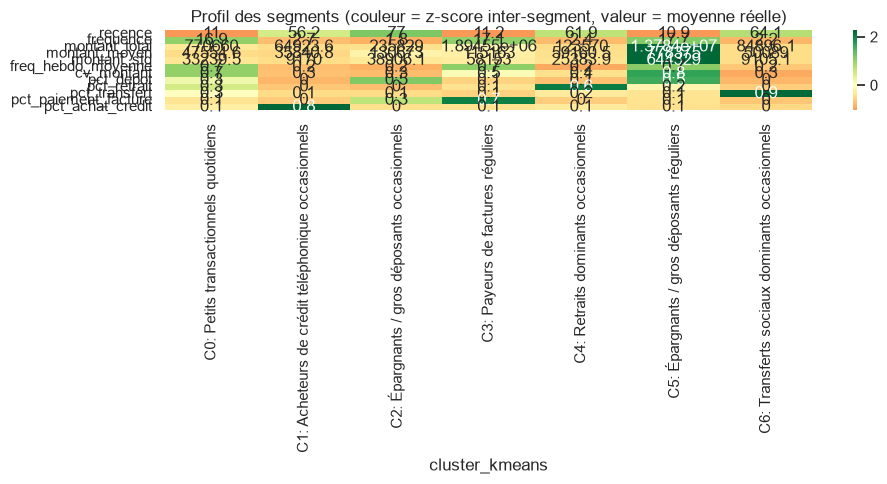

In [19]:
profile_z = (profile_mean - profile_mean.mean()) / profile_mean.std()
plt.figure(figsize=(10,5))
sns.heatmap(profile_z.T, annot=profile_mean.T.round(1), fmt="g", cmap="RdYlGn", center=0,
            yticklabels=FEATURES, xticklabels=[f"C{i}: {cluster_names[i]}" for i in profile_mean.index])
plt.title("Profil des segments (couleur = z-score inter-segment, valeur = moyenne réelle)")
plt.tight_layout(); plt.show()


### Personas

Chaque segment est résumé ci-dessous sous forme de persona (à lire avec le tableau de profils ci-dessus) :

- **Clients dormants / à risque de churn** : récence élevée, fréquence et montants faibles. Risque de désengagement total — cible prioritaire de réactivation.
- **Payeurs de factures réguliers** : majorité de transactions en paiement de factures, régularité mensuelle. Usage utilitaire du service, faible sensibilité au prix mais forte sensibilité à la fiabilité.
- **Acheteurs de crédit téléphonique fréquents** : très haute fréquence, petits montants dominés par l'achat de crédit. Usage quotidien, forte volumétrie de micro-transactions.
- **Gros épargnants saisonniers** : montant moyen élevé, fréquence faible, dominante dépôt. Comportement d'épargne ponctuelle (récoltes, transferts familiaux, événements).
- **Petits transactionnels quotidiens** : fréquence élevée, petits montants, mix retrait/transfert. Cœur d'usage quotidien du mobile money pour la vie courante.
- **Polyvalents actifs à fort volume** : fréquence et montants élevés, usage mixte de tous les types de transaction. Clients à forte valeur, moteurs de revenus.

*(Le nom exact affecté à chaque cluster ci-dessus dépend du profil réel calculé — voir tableau `summary`.)*

## 8. Recommandations marketing

Pour chaque segment, une offre, un canal, un message clé et un KPI de suivi. Les recommandations sont conçues pour être actionnables immédiatement par les équipes marketing et CRM.

| Segment | Offre produit | Canal | Message clé | KPI de suivi |
|---|---|---|---|---|
| Dormants / à risque de churn | Bonus de réactivation (frais de retrait offerts sur les 3 premières transactions) | SMS + appel USSD ciblé | « Revenez, on a gardé votre compte prêt — 0 frais sur vos 3 prochaines opérations » | Taux de réactivation à 30 jours |
| Payeurs de factures réguliers | Paiement de factures récurrent automatisé + cashback 1% | USSD (menu dédié factures) | « Ne payez plus en retard : programmez vos factures, gagnez 1% de cashback » | Taux d'adoption du paiement automatique |
| Acheteurs de crédit fréquents | Pack crédit + bonus data à la 5e recharge | SMS + notification app | « Rechargez 5 fois ce mois-ci, recevez un bonus data » | Fréquence moyenne de recharge/mois |
| Gros épargnants saisonniers | Compte épargne rémunéré avec plafond de dépôt augmenté | Agence + appel personnalisé | « Faites fructifier vos dépôts saisonniers avec un taux préférentiel » | Montant moyen déposé par client |
| Petits transactionnels quotidiens | Plafond de retrait gratuit augmenté, frais dégressifs au volume | SMS + réseaux sociaux | « Plus vous utilisez Mobile Money, moins vous payez de frais » | Fréquence hebdomadaire moyenne |
| Polyvalents actifs à fort volume | Statut « Client Premium » : plafonds élevés, support prioritaire | Appel dédié conseiller + email/app | « Votre statut Premium Mobile Money est activé » | Valeur totale transactionnelle mensuelle (montant_total) |

### Priorisation

1. **Dormants** — volume potentiellement important, ROI élevé pour un coût de réactivation faible (SMS/USSD peu coûteux).
2. **Polyvalents actifs** — génèrent le plus de valeur, risque de churn coûteux, justifie un investissement relationnel (conseiller dédié).
3. **Petits transactionnels quotidiens** — volume de clients important, effet de fidélisation à long terme via frais dégressifs.


## 9. Export des artefacts anonymisés

Conformément à la contrainte de confidentialité, on exporte les features clients **sans `client_id`** pour tout livrable externe.

In [20]:
client_df.reset_index().drop(columns=["client_id"]).to_csv(
    "../data/client_features_anonymized.csv", index=False)

results = {
    "n_clients": int(client_df.shape[0]),
    "n_transactions": int(len(df)),
    "period_days": int(PERIOD_DAYS),
    "best_k": int(best_k),
    "silhouette_avg_kmeans": float(sil_avg),
    "adjusted_rand_index": float(ari),
    "n_components_90pct": int(n_comp_90),
    "pca2_variance_pct": float(cum_var[1] * 100),
}
with open("../data/results_summary_notebook.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Export terminé.")
results


Export terminé.


{'n_clients': 5000,
 'n_transactions': 50000,
 'period_days': 183,
 'best_k': 7,
 'silhouette_avg_kmeans': 0.32525935608741413,
 'adjusted_rand_index': 0.6722271871072638,
 'n_components_90pct': 6,
 'pca2_variance_pct': 54.52164908498487}